In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [3]:
import os 

In [4]:
P5hobodf = pd.read_csv('P5_current.csv')
P5hobodf = P5hobodf.dropna()
P5hobodf["Date-Time"] = pd.to_datetime(P5hobodf["Date-Time"]) 
P5hobodf.index = pd.DatetimeIndex(P5hobodf["Date-Time"]) 

In [5]:
P5filtered = hampel(P5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [6]:
P5filtered = pd.DataFrame(P5filtered.filtered_data.to_numpy(), index=P5hobodf.index)

In [7]:
P5hobodf["FilteredTemp"] = P5filtered

In [8]:
# manual data 
P5mandf = pd.read_csv("Well_Sampling_Data_ALL - P5.csv", index_col=False) #Well_Sampling_Data_P5.csv is a placeholder for the csv file with the field measurements from the piezometer of interest. mandf is the placeholder for the dataframe with all of the manual field measurements. 
P5mandf["Date"] = pd.to_datetime(P5mandf["Date"]) #converts the manual date-time values to pandas datetime format. 

In [9]:
#reading in the NOAA air temp data
weatherdf = pd.read_csv("NOAAHastingsDamTemp.csv")
weatherdf["Date"] = pd.to_datetime(weatherdf["Date"])

In [10]:
#reading C5 continuous data
C5hobodf = pd.read_csv("P5_creek_cond_current.csv") 
C5hobodf["Date-Time"] = pd.to_datetime(C5hobodf["Date-Time"]) 
C5hobodf.index = pd.DatetimeIndex(C5hobodf["Date-Time"])

In [11]:
C5hobodf

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids
Date-Time,,,,,,
2024-09-15 14:44:27,2024-09-15 14:44:27,18.115360,621.810730,726.904785,0.351467,404.176971
2024-09-15 14:59:27,2024-09-15 14:59:27,18.186710,623.290527,727.360596,0.351746,405.138824
2024-09-15 15:14:27,2024-09-15 15:14:27,18.293736,624.757141,727.164917,0.351725,406.092133
2024-09-15 15:29:27,2024-09-15 15:29:27,18.290745,624.579834,727.011719,0.351647,405.976868
2024-09-15 15:44:27,2024-09-15 15:44:27,18.255070,624.237183,727.247009,0.351739,405.754150
...,...,...,...,...,...,...
2026-07-21 10:30:00,2026-07-21 10:30:00,19.970829,469.188660,524.592224,0.252322,304.972626
2026-07-21 10:45:00,2026-07-21 10:45:00,20.080936,470.151367,524.313110,0.252235,305.598389
2026-07-21 11:00:00,2026-07-21 11:00:00,20.179142,471.076599,524.139404,0.252194,306.199768


In [12]:
#filtering the C5 data for the outlier spikes where the hobo probe was removed from the piezometer
C5filtered = hampel(C5hobodf["Temperature"], window_size=6, n_sigma=1.5)

In [13]:
C5filtered = pd.DataFrame(C5filtered.filtered_data.to_numpy(), index=C5hobodf.index)

In [14]:
C5hobodf["FilteredTemp"] = C5filtered

In [37]:
import matplotlib.dates as mdates

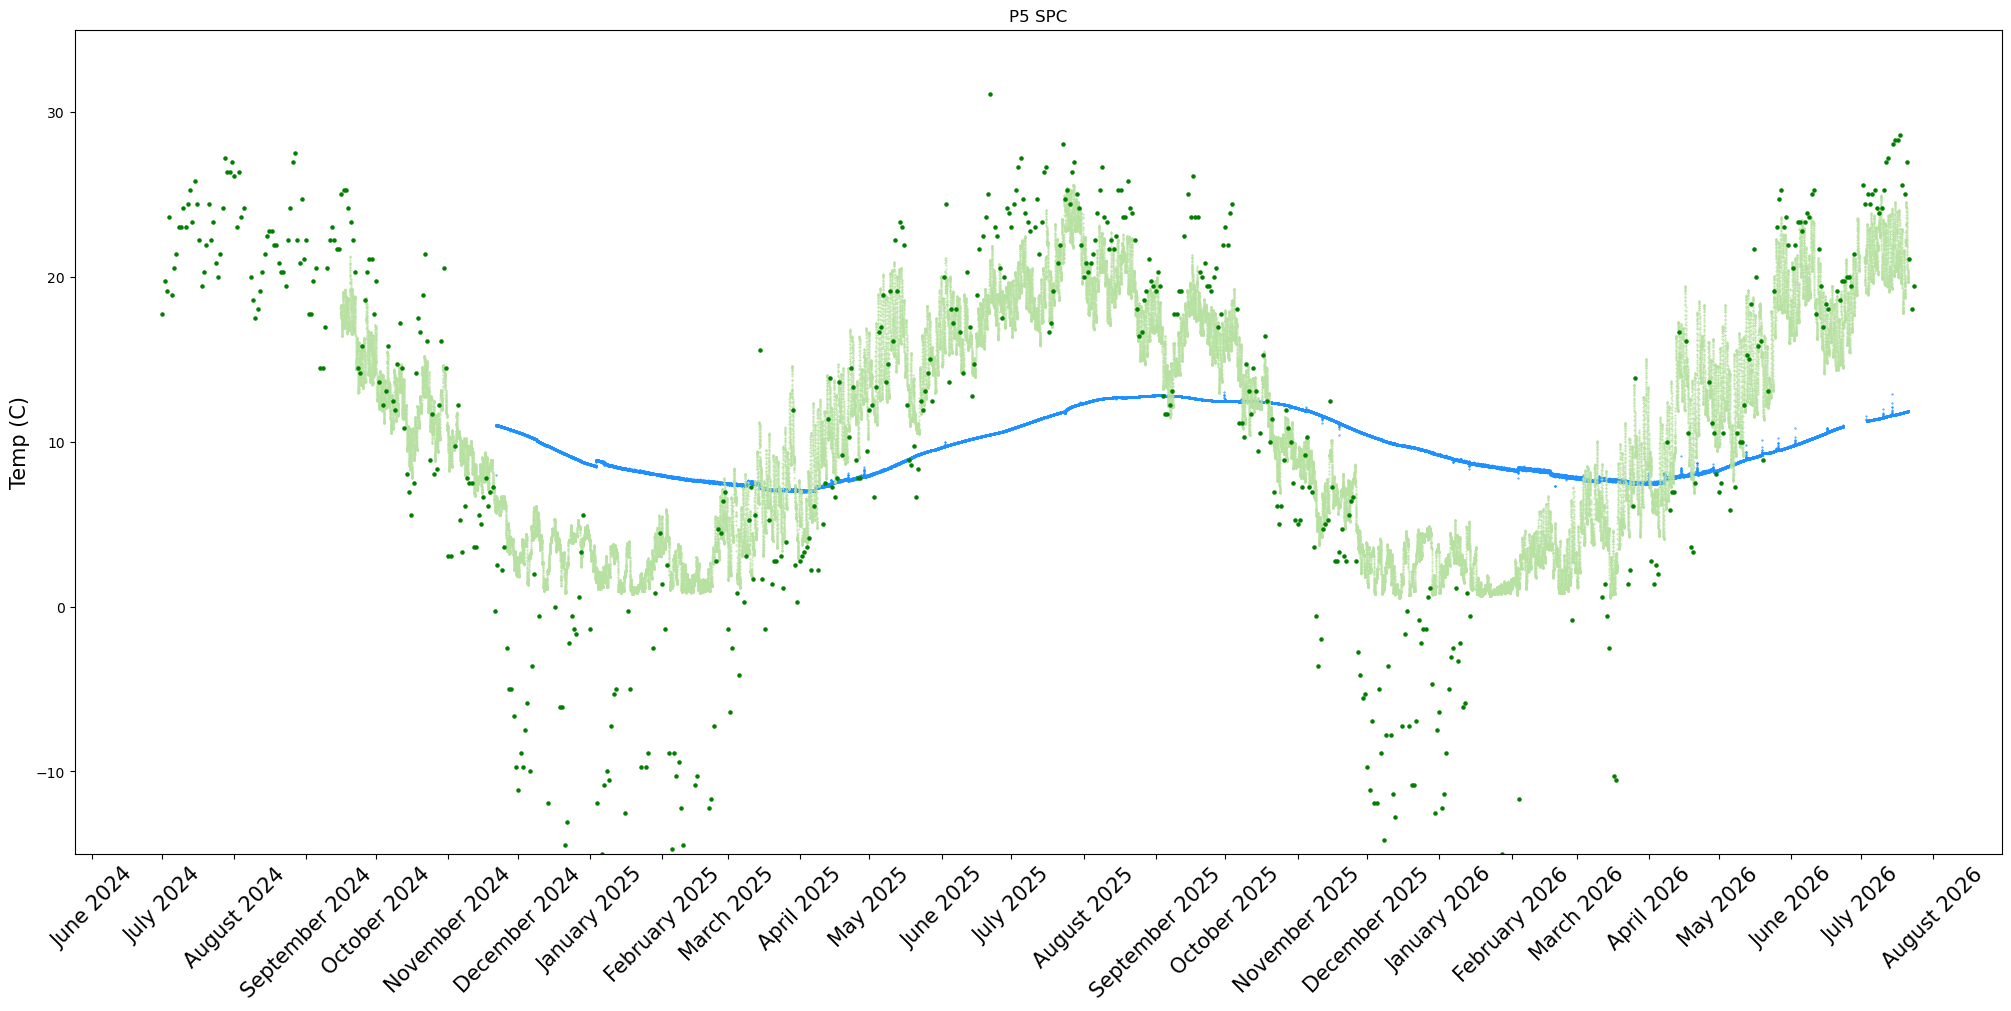

In [45]:
fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))

ax.scatter(P5hobodf.index, P5hobodf.FilteredTemp, color="dodgerblue", s = 0.2, label = "P5 continuous SPC")
# ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
# ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
# ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
# ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")
ax.scatter(C5hobodf.index, C5hobodf.FilteredTemp, color = "xkcd:light grey green", s = 0.2, label = "C5 continuous SPC")
ax.scatter(weatherdf.Date, weatherdf.MeanTempC, color = "green", s = 5, label = "air temperature")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

plt.xticks(rotation=45, fontsize = 15)
# plt.xlabel("Year-Month", fontsize = 15)
plt.ylabel("Temp (C)", fontsize = 15)
plt.title("P5 SPC")

plt.ylim((-15, 35))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
# plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left", fontsize = 20)

#code below places legend on graph and covers some of the data
# ax.legend(location = "outside")

#code below puts legend outside of graph, squishes it down, but is not awful
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

In [50]:
#P5 SPC

In [51]:
#filtering the data to remove the spikes, which are the result of removing the hobo from the well during manual measurements
P5filteredSPC = hampel(P5hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)
P5filteredSPC = pd.DataFrame(P5filteredSPC.filtered_data.to_numpy(), index=P5hobodf.index)

In [52]:
P5filteredSPC.head()

,0
Date-Time,
2024-11-21 11:47:50,146.531219
2024-11-21 12:02:50,483.975128
2024-11-21 12:17:50,484.160583
2024-11-21 12:32:50,484.273224
2024-11-21 12:47:50,484.233643


In [53]:
P5hobodf["FilteredSPC"] = P5filteredSPC

In [54]:
P5hobodf.head()

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,,
2024-11-21 11:47:50,2024-11-21 11:47:50,7.987858,94.182213,146.531219,0.065717,61.218437,7.987858,146.531219
2024-11-21 12:02:50,2024-11-21 12:02:50,10.939152,341.068024,483.975128,0.225773,221.694214,10.939152,483.975128
2024-11-21 12:17:50,2024-11-21 12:17:50,10.966557,341.477356,484.160583,0.225892,221.960266,10.966557,484.160583
2024-11-21 12:32:50,2024-11-21 12:32:50,10.975712,341.649902,484.273224,0.225956,222.072433,10.975712,484.273224
2024-11-21 12:47:50,2024-11-21 12:47:50,10.987888,341.745789,484.233643,0.225951,222.134750,10.987888,484.233643


In [55]:
P5hobodf = P5hobodf[1:] # the first value in after running the hampel filter is too low (because the filter pads the data set with zeros, thus replacing the first value with a number that is a reasonable average if you include the zeros). So, I remove it here. 


In [56]:
C5filtered = hampel(C5hobodf["Specific Conductivity"], window_size=6, n_sigma=1.5)

In [57]:
C5filtered = pd.DataFrame(C5filtered.filtered_data.to_numpy(), index=C5hobodf.index)

In [58]:
C5hobodf["FilteredSPC"] = C5filtered

In [59]:
C5hobodf.head()

,Date-Time,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,,
2024-09-15 14:44:27,2024-09-15 14:44:27,18.115360,621.810730,726.904785,0.351467,404.176971,18.115360,726.904785
2024-09-15 14:59:27,2024-09-15 14:59:27,18.186710,623.290527,727.360596,0.351746,405.138824,18.186710,727.360596
2024-09-15 15:14:27,2024-09-15 15:14:27,18.293736,624.757141,727.164917,0.351725,406.092133,18.293736,727.164917
2024-09-15 15:29:27,2024-09-15 15:29:27,18.290745,624.579834,727.011719,0.351647,405.976868,18.290745,727.247009
2024-09-15 15:44:27,2024-09-15 15:44:27,18.255070,624.237183,727.247009,0.351739,405.754150,18.255070,727.247009


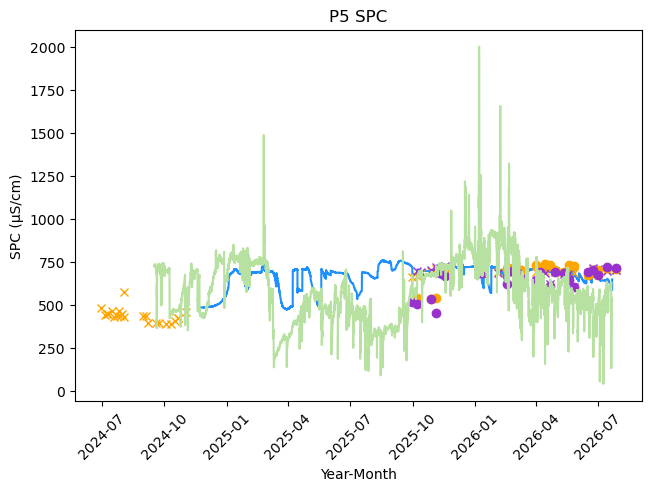

In [60]:
fig, ax = plt.subplots(layout='constrained')

ax.plot(P5hobodf.index, P5hobodf.FilteredSPC, color="dodgerblue", label = "P5 continuous SPC")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top before"], 'x', color = "orange", label = "manual SPC at top before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom before"], 'x', color = "darkorchid", label = "manual SPC at bottom before pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC top after"], 'o', color = "orange", label = "manual SPC at top after pumping")
ax.plot(P5mandf.Date, P5mandf.loc[:,"SPC bottom after"], 'o', color = "darkorchid", label = "manual SPC at bottom after pumping")

plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P5 SPC")

# add C5 SPC for comparison
ax.plot(C5hobodf.index, C5hobodf.FilteredSPC, color = "xkcd:light grey green", label = 'creek SPC at P5')
# plt.ylim((700, 750))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-02")))
#code below places legend outside graph, but squishes it
#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")

#code below places legend on graph and covers some of the data
#ax.legend(loc="lower left")

#code below puts legend outside of graph, squishes it down, but is not awful
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

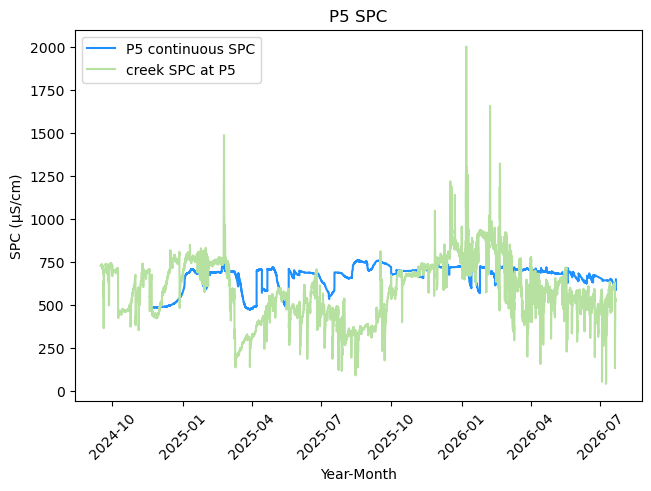

In [61]:
fig, ax = plt.subplots(layout='constrained')
ax.plot(P5hobodf.index, P5hobodf.FilteredSPC, color="dodgerblue", label = "P5 continuous SPC")
ax.plot(C5hobodf.index, C5hobodf.FilteredSPC, color = "xkcd:light grey green", label = 'creek SPC at P5')
plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("SPC (µS/cm)")
plt.title("P5 SPC")
ax.legend()

plt.show()

In [62]:
precip = pd.read_csv("NOAAFaribaultPrecipitation.csv")
precip["Date"] = pd.to_datetime(precip["Date"])
precip = precip[precip["PrecipitationCM"] != 0]

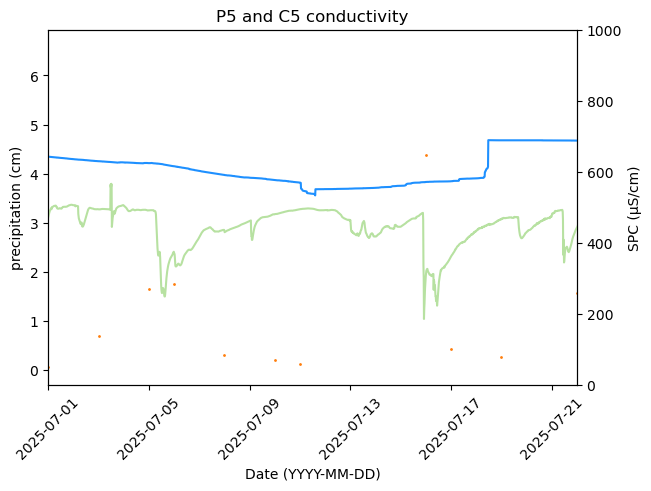

In [63]:
fig, ax1 = plt.subplots(layout='constrained')
ax1.set_xlabel('Date (YYYY-MM-DD)')
ax1.set_ylabel('precipitation (cm)')
rain = ax1.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax.scatter(weatherdf.Date, weatherdf.loc[:,"Mean  Celcius Teperature"], color = "green", s = 1, label = "air temperature")

ax1.tick_params(axis='x', rotation=45)
# ax1.set_ylim(0, 3)


ax2 = ax1.twinx() 
ax2.set_ylabel('SPC (µS/cm)') 
P5 = ax2.plot(P5hobodf.index, P5hobodf.FilteredSPC, color="dodgerblue", label = "P5 continuous SPC")
C5 = ax2.plot(C5hobodf.index, C5hobodf.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P5')
ax2.set_ylim(0, 1000)
ax2.set_xlim((pd.to_datetime("2025-07-01"), pd.to_datetime("2025-07-22")))

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("P5 and C5 conductivity")
# leg = rain + C5 + C1
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04"), pd.to_datetime("2025-05"))

plt.show();

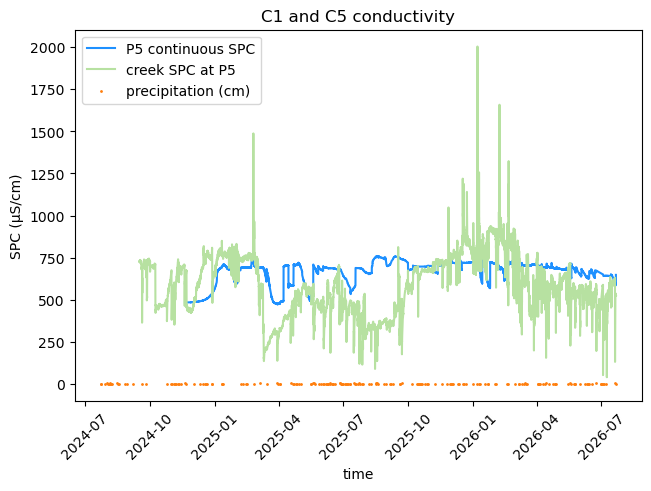

In [64]:
#this is just to make a legend that works
fig, ax = plt.subplots(layout='constrained')
ax.set_xlabel('time')
ax.set_ylabel('SPC (µS/cm)')
P5 = ax.plot(P5hobodf.index, P5hobodf.FilteredSPC, color="dodgerblue", label = "P5 continuous SPC")
C5 = ax.plot(C5hobodf.index, C5hobodf.FilteredSPC,  color = "xkcd:light grey green", label = 'creek SPC at P5')
ax.tick_params(axis='x', rotation=45)

rain = ax.scatter(precip.Date, precip.PrecipitationCM, alpha = 1, s= 1, color = 'tab:orange', label = "precipitation (cm)")
# ax2.plot((precip.Date, precip.PrecipitationCM))
# ax2.tick_params(axis='y', labelcolor=color)
# ax.twinx.plot(precip.Date, precip.PrecipitationCM, color = "bisque", alpha = 0.5, label = "precipitation (cm)")

plt.xticks(rotation=45)
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
plt.title("C1 and C5 conductivity")

plt.legend()
# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show();

In [65]:
# resampling spc so that I can plot creek against piezometer
P5hobodf.set_index('Date-Time', inplace=True)
# P5hobodf = P5hobodf.resample('D').mean()
P5hobodf.index = P5hobodf.index.round('15min')

In [66]:
P5hobodf.head()

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2024-11-21 12:00:00,10.939152,341.068024,483.975128,0.225773,221.694214,10.939152,483.975128
2024-11-21 12:15:00,10.966557,341.477356,484.160583,0.225892,221.960266,10.966557,484.160583
2024-11-21 12:30:00,10.975712,341.649902,484.273224,0.225956,222.072433,10.975712,484.273224
2024-11-21 12:45:00,10.987888,341.745789,484.233643,0.225951,222.134750,10.987888,484.233643
2024-11-21 13:00:00,10.994022,341.678223,484.049561,0.225870,222.090836,10.994022,484.181671


In [67]:
C5hobodf.set_index('Date-Time', inplace=True)
# C5hobodf = C5hobodf.resample('D').mean()

In [68]:
C5hobodf.index = C5hobodf.index.round('15min')

In [69]:
C5hobodf = C5hobodf.tail(len(P5hobodf))

In [70]:
print("X shape:", C5hobodf.FilteredSPC.shape, "Total size:", C5hobodf.FilteredSPC.size)
print("Y shape:", P5hobodf.FilteredSPC.shape, "Total size:", P5hobodf.FilteredSPC.size)

X shape: (57296,) Total size: 57296
Y shape: (57296,) Total size: 57296


In [71]:
duplicate_rows = C5hobodf.loc[C5hobodf.index.duplicated()]
print(duplicate_rows)

                     Temperature  Electrical Conductivity  \
Date-Time                                                   
2025-11-02 01:15:00     8.533085               444.011444   
2025-11-02 01:30:00     8.489567               443.426178   
2025-11-02 01:45:00     8.442936               443.019531   
2025-11-02 02:00:00     8.396244               442.483459   

                     Specific Conductivity  Salinity  Total Dissolved Solids  \
Date-Time                                                                      
2025-11-02 01:15:00             678.714417  0.315925              288.607422   
2025-11-02 01:30:00             678.768005  0.315869              288.227020   
2025-11-02 01:45:00             679.163574  0.315972              287.962677   
2025-11-02 02:00:00             679.362976  0.315979              287.614227   

                     FilteredTemp  FilteredSPC  
Date-Time                                       
2025-11-02 01:15:00      8.533085   678.714417  
2025-

In [72]:
P5hobodf = P5hobodf.loc[~P5hobodf.index.duplicated(keep='first')]

In [73]:
C5hobodf = C5hobodf.loc[~C5hobodf.index.duplicated(keep='first')]

In [74]:
P5hobodf.to_csv(r'C:\Users\HydroResearch\Documents\GitHub\summer_26\summer 2026\P5hobodf.csv')

In [75]:
P5hobodf

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2024-11-21 12:00:00,10.939152,341.068024,483.975128,0.225773,221.694214,10.939152,483.975128
2024-11-21 12:15:00,10.966557,341.477356,484.160583,0.225892,221.960266,10.966557,484.160583
2024-11-21 12:30:00,10.975712,341.649902,484.273224,0.225956,222.072433,10.975712,484.273224
2024-11-21 12:45:00,10.987888,341.745789,484.233643,0.225951,222.134750,10.987888,484.233643
2024-11-21 13:00:00,10.994022,341.678223,484.049561,0.225870,222.090836,10.994022,484.181671
...,...,...,...,...,...,...,...
2026-07-21 10:15:00,11.845036,423.924194,585.736328,0.275922,275.550720,11.845036,585.736328
2026-07-21 10:30:00,11.845036,424.031097,585.884033,0.275993,275.620209,11.845036,585.884033
2026-07-21 10:45:00,11.845036,423.945526,585.765808,0.275936,275.564575,11.845036,585.765808


In [76]:
C5hobodf

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2024-11-29 08:15:00,2.224247,228.524399,438.030243,0.190128,148.540848,2.224247,438.030243
2024-11-29 08:30:00,2.224247,233.329758,447.241028,0.194289,151.664337,2.224247,438.563171
2024-11-29 08:45:00,2.217563,233.191025,447.095367,0.194208,151.574158,2.217563,438.563171
2024-11-29 09:00:00,2.197422,228.203537,437.888031,0.190003,148.332291,2.217563,437.888031
2024-11-29 09:15:00,2.200779,229.375412,440.077148,0.190999,149.094009,2.200779,440.077148
...,...,...,...,...,...,...,...
2026-07-21 10:30:00,19.970829,469.188660,524.592224,0.252322,304.972626,19.970829,524.592224
2026-07-21 10:45:00,20.080936,470.151367,524.313110,0.252235,305.598389,20.080936,524.313110
2026-07-21 11:00:00,20.179142,471.076599,524.139404,0.252194,306.199768,20.179142,524.139404


In [77]:
P5hobodf = P5hobodf.reindex_like(C5hobodf, method = None)

In [78]:
P5hobodf

,Temperature,Electrical Conductivity,Specific Conductivity,Salinity,Total Dissolved Solids,FilteredTemp,FilteredSPC
Date-Time,,,,,,,
2024-11-29 08:15:00,10.658360,339.486176,485.795288,0.226328,220.666000,10.661411,485.576965
2024-11-29 08:30:00,10.661411,339.364716,485.576965,0.226227,220.587051,10.658360,485.576965
2024-11-29 08:45:00,10.658360,339.205109,485.393097,0.226135,220.483307,10.658360,485.393097
2024-11-29 09:00:00,10.658360,339.323212,485.562103,0.226216,220.560074,10.658360,485.562103
2024-11-29 09:15:00,10.658360,339.272064,485.488892,0.226181,220.526840,10.658360,485.576965
...,...,...,...,...,...,...,...
2026-07-21 10:30:00,11.845036,424.031097,585.884033,0.275993,275.620209,11.845036,585.884033
2026-07-21 10:45:00,11.845036,423.945526,585.765808,0.275936,275.564575,11.845036,585.765808
2026-07-21 11:00:00,11.845036,423.883179,585.679688,0.275894,275.524048,11.845036,585.679688


In [ ]:
C5hobodf

In [80]:
C5hobodf['mos'] = C5hobodf.index.to_period('M')

In [81]:
C5hobodf['mos'] = C5hobodf.mos.dt.strftime('%B %Y')

In [82]:
P5hobodf['mos'] = P5hobodf.index.to_period('M')

In [83]:
P5hobodf['mos'] = P5hobodf.mos.dt.strftime('%B %Y')

In [86]:
month = C5hobodf.mos.unique()

In [87]:
print(month)

<StringArray>
[ 'November 2024',  'December 2024',   'January 2025',  'February 2025',
     'March 2025',     'April 2025',       'May 2025',      'June 2025',
      'July 2025',    'August 2025', 'September 2025',   'October 2025',
  'November 2025',  'December 2025',   'January 2026',  'February 2026',
     'March 2026',     'April 2026',       'May 2026',      'June 2026',
      'July 2026']
Length: 21, dtype: str


In [89]:
# from gemini

import matplotlib.colors as mcolors

cmap = plt.get_cmap('gist_rainbow')
rainbow_21 = [mcolors.to_hex(cmap(i)) for i in np.linspace(0, 1, 21)]

print(rainbow_21)


['#ff0029', '#ff1800', '#ff5e00', '#ffa400', '#ffea00', '#cdff00', '#8dff00', '#46ff00', '#00ff00', '#00ff46', '#00ff8c', '#00ffcc', '#00ecff', '#00a5ff', '#005eff', '#0018ff', '#2a00ff', '#7000ff', '#b700ff', '#fe00ff', '#ff00bf']


In [92]:
colors = {'November 2024':'#ff1800', 'December 2024':'#ff1800', 'January 2025':'#ff5e00', 'February 2025':'#ffa400', 'March 2025': '#ffea00', 'April 2025':'#cdff00', 'May 2025':'#8dff00', 'June 2025':'#46ff00', 'July 2025':'#00ff00', 'August 2025':'#00ff46', 'September 2025':'#00ff8c', 'October 2025':'#00ffcc', 'November 2025': '#00ecff', 'December 2025':'#00a5ff', 'January 2026':'#005eff', 'February 2026':'#0018ff', 'March 2026':'#2a00ff', 'April 2026':'#7000ff', 'May 2026':'#b700ff', 'June 2026':'#fe00ff', 'July 2026':'#ff00bf'}

In [93]:
left = C5hobodf
right = P5hobodf

In [95]:
stat5 = pd.merge(left, right, on = 'Date-Time')

In [96]:
stat5

,Temperature_x,Electrical Conductivity_x,Specific Conductivity_x,Salinity_x,Total Dissolved Solids_x,FilteredTemp_x,FilteredSPC_x,mos_x,Temperature_y,Electrical Conductivity_y,Specific Conductivity_y,Salinity_y,Total Dissolved Solids_y,FilteredTemp_y,FilteredSPC_y,mos_y
Date-Time,,,,,,,,,,,,,,,,
2024-11-29 08:15:00,2.224247,228.524399,438.030243,0.190128,148.540848,2.224247,438.030243,November 2024,10.658360,339.486176,485.795288,0.226328,220.666000,10.661411,485.576965,November 2024
2024-11-29 08:30:00,2.224247,233.329758,447.241028,0.194289,151.664337,2.224247,438.563171,November 2024,10.661411,339.364716,485.576965,0.226227,220.587051,10.658360,485.576965,November 2024
2024-11-29 08:45:00,2.217563,233.191025,447.095367,0.194208,151.574158,2.217563,438.563171,November 2024,10.658360,339.205109,485.393097,0.226135,220.483307,10.658360,485.393097,November 2024
2024-11-29 09:00:00,2.197422,228.203537,437.888031,0.190003,148.332291,2.217563,437.888031,November 2024,10.658360,339.323212,485.562103,0.226216,220.560074,10.658360,485.562103,November 2024
2024-11-29 09:15:00,2.200779,229.375412,440.077148,0.190999,149.094009,2.200779,440.077148,November 2024,10.658360,339.272064,485.488892,0.226181,220.526840,10.658360,485.576965,November 2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-21 10:30:00,19.970829,469.188660,524.592224,0.252322,304.972626,19.970829,524.592224,July 2026,11.845036,424.031097,585.884033,0.275993,275.620209,11.845036,585.884033,July 2026
2026-07-21 10:45:00,20.080936,470.151367,524.313110,0.252235,305.598389,20.080936,524.313110,July 2026,11.845036,423.945526,585.765808,0.275936,275.564575,11.845036,585.765808,July 2026
2026-07-21 11:00:00,20.179142,471.076599,524.139404,0.252194,306.199768,20.179142,524.139404,July 2026,11.845036,423.883179,585.679688,0.275894,275.524048,11.845036,585.679688,July 2026


In [98]:
# stat1["mos_x"], unique_categories = pd.factorize(df["category_column"])

In [ ]:
mdates.date2num(df['Timestamp'])

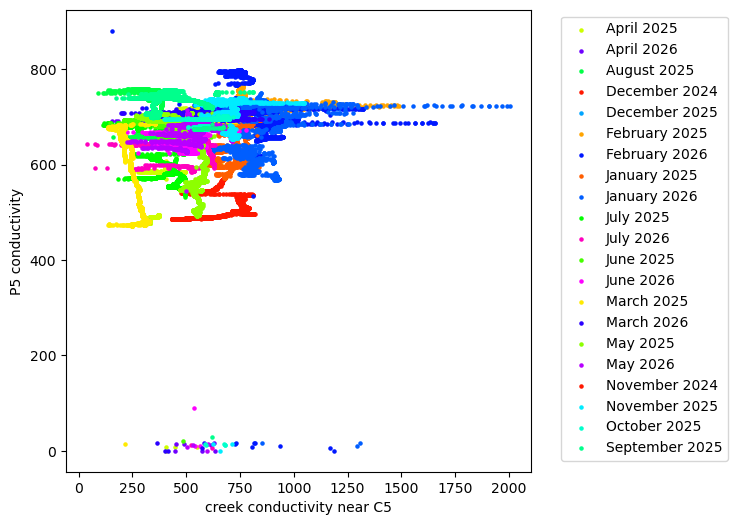

In [99]:
# Source - https://stackoverflow.com/a/26139658
# Posted by Ffisegydd, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-29, License - CC BY-SA 4.0

fig, ax = plt.subplots(figsize=(6, 6))

grouped = stat5.groupby('mos_x')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='Specific Conductivity_x', y='Specific Conductivity_y', s = 5, label=key, color=colors[key])

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('P5 conductivity')
plt.xlabel('creek conductivity near C5')
plt.show()


In [ ]:
fig, ax = plt.subplots(layout='constrained')

scatter = ax.scatter(creek.FilteredSPC, P5hobodf.FilteredSPC, c = creek.index, cmap = 'viridis')
plt.ylabel("daily average C5 SPC")
plt.xlabel("daily average P5 SPC")
# cbar = plt.colorbar(scatter,  
#         ticks=np.unique(creek.index))

plt.plot()